---
embed-resources: True
format:
    html:
        page-layout: full
        fontsize: 16px
title: 'Baseline vs best solution'
author: 'Lorenzo Marquesini'
toc: False
---

# Baseline vs best solution

Comparamos la solución **histórica (baseline)** reconstruida desde los datos del problema
con la **mejor solución bajo restricciones actuales** (`+10.11098`, g=3.0).

In [16]:
from pathlib import Path

import pandas as pd

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())

import sys

sys.path.insert(0, str(ROOT / "src"))

from evaluate import SUBMISSION_COLS, agregar_id_tipo_caja, evaluar_costos_solucion
from mark16 import costo_actual_oficial, score_publico

ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
pj = pd.read_csv(ROOT / "data/processed/producto_joined_cajas_clean.csv")

TABLES = ROOT / "outputs" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)
BASELINE_PATH = TABLES / "00_baseline_solution.csv"
BEST_PATH = TABLES / "04_mark15_best_+10.11098csv"

print(f"ROOT = {ROOT}")

ROOT = /home/lorenn/Desktop/Universidad/Competencia-AlixPartners


## 1. Solución baseline

Asignación histórica producto → caja desde `producto_joined_cajas_clean.csv`
(mismas columnas que un submission). Si el CSV no existe, lo creamos.

In [17]:
def build_baseline_solution(joined: pd.DataFrame) -> pd.DataFrame:
    missing = [c for c in SUBMISSION_COLS if c not in joined.columns]
    if missing:
        raise ValueError(f"Faltan columnas para armar baseline: {missing}")
    sol = joined[SUBMISSION_COLS].copy()
    sol["codigo_producto"] = sol["codigo_producto"].astype(str).str.strip()
    for c in SUBMISSION_COLS[1:]:
        sol[c] = pd.to_numeric(sol[c], errors="coerce")
    if sol.isna().any().any():
        raise ValueError("Baseline con NaNs en dimensiones/grosor")
    return sol.sort_values("codigo_producto").reset_index(drop=True)


baseline = build_baseline_solution(pj)
baseline.to_csv(BASELINE_PATH, index=False)

print(f"Baseline guardada en {BASELINE_PATH.relative_to(ROOT)}")
print(f"  productos: {len(baseline)}")
print(f"  grosores:  {sorted(baseline['caja_grosor_mm'].round(1).unique())}")
baseline.head()

Baseline guardada en outputs/tables/00_baseline_solution.csv
  productos: 427
  grosores:  [np.float64(2.5), np.float64(2.7), np.float64(4.1), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8)]


,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,4.1,394.2,294.2,311.2
1,BR0002,2.7,400.0,301.4,265.4
2,BR0003,4.1,396.2,296.2,172.2
3,BR0004,2.7,400.0,301.4,229.4
4,BR0005,4.1,394.2,294.2,261.2


## 2. Mejor solución (restricciones actuales)

CSV Mark 15/16 con score público **+10.11098** (grosor único 3.0 mm).

In [18]:
if not BEST_PATH.exists():
    raise FileNotFoundError(f"No se encontró la mejor solución: {BEST_PATH}")

best = pd.read_csv(BEST_PATH)[SUBMISSION_COLS].copy()
best["codigo_producto"] = best["codigo_producto"].astype(str).str.strip()

print(f"Best cargada desde {BEST_PATH.relative_to(ROOT)}")
print(f"  productos: {len(best)}")
print(f"  grosores:  {sorted(best['caja_grosor_mm'].round(1).unique())}")
best.head()

Best cargada desde outputs/tables/04_mark15_best_+10.11098csv
  productos: 427
  grosores:  [np.float64(3.0)]


,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,3.0,400.0,300.0,300.00
1,BR0002,3.0,400.0,300.0,271.95
2,BR0003,3.0,400.0,300.0,179.40
3,BR0004,3.0,400.0,300.0,244.29
4,BR0005,3.0,400.0,300.0,257.14


## 3. Tipos de caja y costo total

- **Cantidad de cajas** = tipos de caja distintos (geometría + grosor).
- **Baseline:** costo oficial del problema (`operaciones_planta`).
- **Best:** costo bajo el evaluador actual (packaging por tiers + flete USD 150/pallet).

In [19]:
def n_tipos_caja(sol: pd.DataFrame) -> int:
    return int(agregar_id_tipo_caja(sol)["caja_tipo_id_solucion"].nunique())


costo_baseline = costo_actual_oficial(ops)
n_baseline = n_tipos_caja(baseline)

ev_best = evaluar_costos_solucion(best, ops)
res_best = ev_best["resumen"].iloc[0]
costo_best = float(res_best["costo_total_nuevo"])
n_best = int(res_best["n_tipos_caja"])

resumen = pd.DataFrame(
    [
        {
            "solucion": "Baseline (histórica)",
            "n_tipos_caja": n_baseline,
            "costo_total_USD": costo_baseline,
            "score": 0.0,
        },
        {
            "solucion": "Best (+10.11098)",
            "n_tipos_caja": n_best,
            "costo_total_USD": costo_best,
            "score": score_publico(costo_best, costo_baseline),
        },
    ]
)

for _, row in resumen.iterrows():
    print(
        f"{row['solucion']}: "
        f"{int(row['n_tipos_caja'])} tipos de caja | "
        f"costo total USD {row['costo_total_USD']:,.2f} | "
        f"score {row['score']:+.5f}"
    )

print()
print(
    f"Delta: {n_baseline - n_best} tipos menos | "
    f"ahorro USD {costo_baseline - costo_best:,.2f}"
)

resumen

Baseline (histórica): 204 tipos de caja | costo total USD 209,235,093.94 | score +0.00000
Best (+10.11098): 56 tipos de caja | costo total USD 187,584,964.20 | score +10.34727

Delta: 148 tipos menos | ahorro USD 21,650,129.74


,solucion,n_tipos_caja,costo_total_USD,score
0,Baseline (histórica),204,2.092351e+08,0.000000
1,Best (+10.11098),56,1.875850e+08,10.347275


## 4. Waterfall — Baseline → Best

Barras de costo total con el ahorro en el medio (USD y % de mejora sobre baseline).


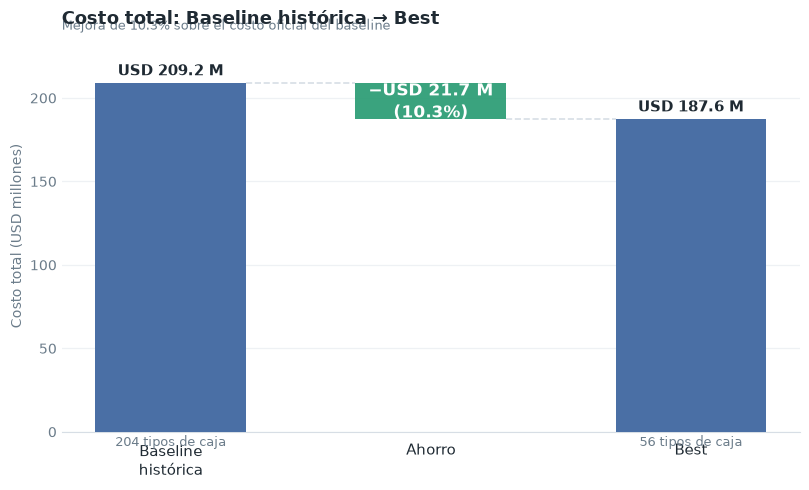

Ahorro: USD 21,650,129.74  |  Mejora: 10.35%


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ahorro = costo_baseline - costo_best
mejora_pct = 100.0 * ahorro / costo_baseline

# ── paleta limpia ──────────────────────────────────────────────
INK = "#1F2A33"
MUTED = "#6B7C8A"
LIGHT = "#D7DEE5"
TOTAL_C = "#4A6FA5"   # totales (baseline / best)
SAVE_C = "#2F9E77"    # puente de ahorro
BG = "#FFFFFF"

labels = ["Baseline\nhistórica", "Ahorro", "Best"]
values = np.array([costo_baseline, -ahorro, costo_best]) / 1e6  # USD M
# bottoms: baseline from 0; ahorro floats from best up to baseline; best from 0
bottoms = np.array([0.0, costo_best, 0.0]) / 1e6
colors = [TOTAL_C, SAVE_C, TOTAL_C]
alphas = [1.0, 0.95, 1.0]

fig, ax = plt.subplots(figsize=(8.2, 5.0), facecolor=BG)
ax.set_facecolor(BG)

x = np.arange(3)
width = 0.58
bars = ax.bar(
    x, np.abs(values), bottom=bottoms, width=width,
    color=colors, edgecolor="none", zorder=3,
)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)

# conector baseline → best (línea guía del waterfall)
ax.plot(
    [0 + width / 2, 1 - width / 2],
    [costo_baseline / 1e6, costo_baseline / 1e6],
    color=LIGHT, lw=1.2, ls="--", zorder=2,
)
ax.plot(
    [1 + width / 2, 2 - width / 2],
    [costo_best / 1e6, costo_best / 1e6],
    color=LIGHT, lw=1.2, ls="--", zorder=2,
)

# etiquetas de valor
ax.text(
    0, costo_baseline / 1e6 + 2.2,
    f"USD {costo_baseline / 1e6:.1f} M",
    ha="center", va="bottom", fontsize=11, fontweight="bold", color=INK,
)
ax.text(
    1, (costo_baseline + costo_best) / 2e6,
    f"−USD {ahorro / 1e6:.1f} M\n({mejora_pct:.1f}%)",
    ha="center", va="center", fontsize=12, fontweight="bold", color="white",
    linespacing=1.35,
)
ax.text(
    2, costo_best / 1e6 + 2.2,
    f"USD {costo_best / 1e6:.1f} M",
    ha="center", va="bottom", fontsize=11, fontweight="bold", color=INK,
)

# subtítulos con tipos de caja
ax.text(0, -8.5, f"{n_baseline} tipos de caja", ha="center", fontsize=9, color=MUTED)
ax.text(2, -8.5, f"{n_best} tipos de caja", ha="center", fontsize=9, color=MUTED)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color=INK)
ax.set_ylabel("Costo total (USD millones)", fontsize=10, color=MUTED)
ax.set_ylim(0, costo_baseline / 1e6 * 1.12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.yaxis.grid(True, color="#EEF1F4", lw=0.9, zorder=0)
ax.set_axisbelow(True)

for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(LIGHT)
ax.tick_params(axis="y", colors=MUTED, length=0)
ax.tick_params(axis="x", length=0, pad=8)

ax.set_title(
    "Costo total: Baseline histórica → Best",
    fontsize=13, fontweight="bold", color=INK, loc="left", pad=12,
)
ax.text(
    0, 1.02,
    f"Mejora de {mejora_pct:.1f}% sobre el costo oficial del baseline",
    transform=ax.transAxes, fontsize=9.5, color=MUTED, va="bottom",
)

plt.tight_layout()
plt.show()

print(f"Ahorro: USD {ahorro:,.2f}  |  Mejora: {mejora_pct:.2f}%")


## 5. Packaging vs flete

Desglose del costo: packaging a la izquierda, envío (flete) a la derecha.


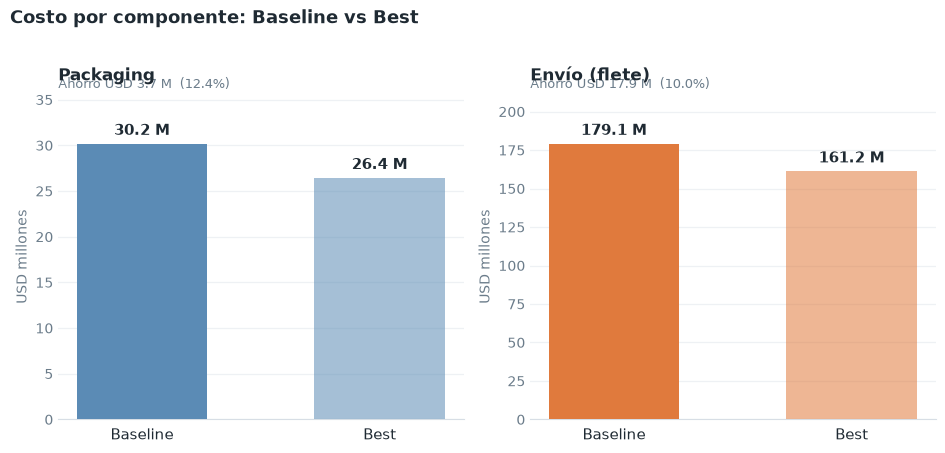

Packaging: 30,166,294 → 26,426,764  (−12.4%)
Flete:     179,068,800 → 161,158,200  (−10.0%)


In [21]:
pack_baseline = float(ops["costo_total"].sum())
flete_baseline = float(ops["costo_pallets_total"].sum())
pack_best = float(res_best["costo_packaging_nuevo"])
flete_best = float(res_best["costo_flete_nuevo"])

paneles = [
    ("Packaging", pack_baseline, pack_best, "#5B8BB5"),
    ("Envío (flete)", flete_baseline, flete_best, "#E07A3D"),
]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4), facecolor=BG, sharey=False)
fig.suptitle(
    "Costo por componente: Baseline vs Best",
    fontsize=13, fontweight="bold", color=INK, x=0.01, ha="left", y=1.02,
)

x = np.arange(2)
width = 0.55

for ax, (titulo, v_base, v_best, color) in zip(axes, paneles):
    ax.set_facecolor(BG)
    vals = np.array([v_base, v_best]) / 1e6
    bars = ax.bar(x, vals, width=width, color=[color, color], edgecolor="none", zorder=3)
    bars[1].set_alpha(0.55)

    delta = v_base - v_best
    pct = 100.0 * delta / v_base if v_base else 0.0

    for i, v in enumerate(vals):
        ax.text(
            i, v + max(vals) * 0.02,
            f"{v:.1f} M",
            ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=INK,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Baseline", "Best"], fontsize=11, color=INK)
    ax.set_ylabel("USD millones", fontsize=10, color=MUTED)
    ax.set_title(titulo, fontsize=12, fontweight="bold", color=INK, loc="left", pad=10)
    ax.text(
        0.0, 1.01,
        f"Ahorro USD {delta / 1e6:.1f} M  ({pct:.1f}%)",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom",
    )

    ax.set_ylim(0, max(vals) * 1.18)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.yaxis.grid(True, color="#EEF1F4", lw=0.9, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(LIGHT)
    ax.tick_params(axis="y", colors=MUTED, length=0)
    ax.tick_params(axis="x", length=0, pad=6)

plt.tight_layout()
plt.show()

print(
    f"Packaging: {pack_baseline:,.0f} → {pack_best:,.0f}  "
    f"(−{100 * (pack_baseline - pack_best) / pack_baseline:.1f}%)"
)
print(
    f"Flete:     {flete_baseline:,.0f} → {flete_best:,.0f}  "
    f"(−{100 * (flete_baseline - flete_best) / flete_baseline:.1f}%)"
)


## 6. Peso del flete en el costo total

Qué porcentaje del costo total es flete (vs packaging) en Baseline y en Best.


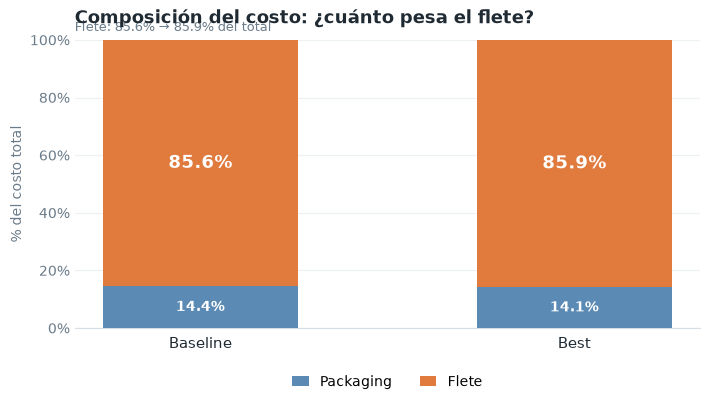

Baseline: flete 85.6% | packaging 14.4% (total USD 209.2 M)
Best: flete 85.9% | packaging 14.1% (total USD 187.6 M)


In [22]:
escenarios = ["Baseline", "Best"]
flete_vals = np.array([flete_baseline, flete_best])
pack_vals = np.array([pack_baseline, pack_best])
totales = flete_vals + pack_vals
pct_flete = 100.0 * flete_vals / totales
pct_pack = 100.0 * pack_vals / totales

PACK_C = "#5B8BB5"
FLETE_C = "#E07A3D"

fig, ax = plt.subplots(figsize=(7.2, 4.2), facecolor=BG)
ax.set_facecolor(BG)

x = np.arange(len(escenarios))
width = 0.52

b_pack = ax.bar(x, pct_pack, width=width, color=PACK_C, edgecolor="none", label="Packaging", zorder=3)
b_flete = ax.bar(
    x, pct_flete, width=width, bottom=pct_pack,
    color=FLETE_C, edgecolor="none", label="Flete", zorder=3,
)

for i, (pf, pp) in enumerate(zip(pct_flete, pct_pack)):
    # etiqueta flete (dominante)
    ax.text(
        i, pp + pf / 2,
        f"{pf:.1f}%",
        ha="center", va="center", fontsize=13, fontweight="bold", color="white",
    )
    # etiqueta packaging
    ax.text(
        i, pp / 2,
        f"{pp:.1f}%",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(escenarios, fontsize=11, color=INK)
ax.set_ylabel("% del costo total", fontsize=10, color=MUTED)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.yaxis.grid(True, color="#EEF1F4", lw=0.9, zorder=0)
ax.set_axisbelow(True)

for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(LIGHT)
ax.tick_params(axis="y", colors=MUTED, length=0)
ax.tick_params(axis="x", length=0, pad=6)

ax.set_title(
    "Composición del costo: ¿cuánto pesa el flete?",
    fontsize=13, fontweight="bold", color=INK, loc="left", pad=12,
)
ax.text(
    0, 1.02,
    f"Flete: {pct_flete[0]:.1f}% → {pct_flete[1]:.1f}% del total",
    transform=ax.transAxes, fontsize=9.5, color=MUTED, va="bottom",
)

ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12),
    ncol=2, fontsize=10, handlelength=1.2,
)

plt.tight_layout()
plt.show()

for nombre, pf, pp, tot in zip(escenarios, pct_flete, pct_pack, totales):
    print(
        f"{nombre}: flete {pf:.1f}% | packaging {pp:.1f}% "
        f"(total USD {tot / 1e6:.1f} M)"
    )
